In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from scipy.ndimage import rotate
import numpy as np

# -----------------------------
# Parameters
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_images = 4         # number of slices per sample
crop = 128
image_size = 128
batch_size = 16
epochs = 50

lr_G = 2e-4
lr_D = 1e-4
beta1 = 0.5
lambda_L1 = 100.0

In [2]:
type(np.array([]))

numpy.ndarray

In [3]:
# -----------------------------
# Forward Projection
# -----------------------------
angles = np.linspace(0, 180, image_size, endpoint=False)

def compute_sinogram(img_tensor):
    if(type(img_tensor) != type(np.array([]))):
        img = img_tensor[0].numpy()
    else:
        img = img_tensor[0]
    sino = []
    for theta in angles:
        rotated = rotate(img, theta, reshape=False, order=1)
        projection = np.sum(rotated, axis=0)
        sino.append(projection)
    return torch.tensor(np.array(sino)).unsqueeze(0)  # (1, H, W)

In [4]:
# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(crop),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [5]:
# -----------------------------
# Load PET dataset
# -----------------------------
pet_base_ds = ImageFolder("D:/New folder/DatasetX/", transform=transform)

In [6]:
# -----------------------------
# Precompute sinograms
# -----------------------------
precomputed_sinos = []
for i in range(len(pet_base_ds)):
    img, _ = pet_base_ds[i]
    sino = compute_sinogram(img)
    precomputed_sinos.append(sino)
precomputed_sinos = torch.stack(precomputed_sinos)  # (N, 1, H, W)

In [7]:
def center_crop_tensor(x, crop_size):
    """
    x: tensor (..., H, W)
    crop_size: int
    """
    _, H, W = x.shape
    top = (H - crop_size) // 2
    left = (W - crop_size) // 2
    return x[:, top:top + crop_size, left:left + crop_size]
# -----------------------------
# Multi-Slice Dataset
# -----------------------------
class MultiSliceDataset(Dataset):
    def __init__(self, pet_dataset, sinos_tensor, num_slices, crop_size=180):
        self.pet_ds = pet_dataset
        self.sinos = sinos_tensor
        self.num_slices = num_slices
        self.crop_size = crop_size

    def __len__(self):
        return len(self.pet_ds) - self.num_slices + 1

    def __getitem__(self, idx):
        # ---------------------
        # PET slices (already transformed)
        # ---------------------
        pet_slices = [self.pet_ds[idx + i][0] for i in range(self.num_slices)]
        pet_stack = torch.cat(pet_slices, dim=0)  # (num_slices, H, W)

        # ---------------------
        # Sinogram slices (crop here)
        # ---------------------
        sino_slices = []
        for i in range(self.num_slices):
            sino = self.sinos[idx + i]          # (1, 256, 256)
            sino = center_crop_tensor(sino, self.crop_size)  # (1, 180, 180)
            sino_slices.append(sino)

        sino_stack = torch.cat(sino_slices, dim=0)  # (num_slices, 180, 180)

        return pet_stack, sino_stack

dataset = MultiSliceDataset(
    pet_base_ds,
    precomputed_sinos,
    num_images,
    crop_size=crop
)

train_dl = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [8]:
class AxialAttention(nn.Module):
    def __init__(self, in_channels, heads=4, dim_head=None):
        super().__init__()

        self.heads = heads
        self.dim_head = dim_head or (in_channels // heads)
        self.inner_dim = self.heads * self.dim_head

        assert in_channels % heads == 0, "in_channels must be divisible by heads"

        # Shared projections
        self.to_qkv = nn.Conv2d(
            in_channels,
            self.inner_dim * 3,
            kernel_size=1,
            bias=False
        )

        self.out = nn.Conv2d(self.inner_dim, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape

        qkv = self.to_qkv(x)
        q, k, v = qkv.chunk(3, dim=1)

        # reshape to (B, heads, dim_head, H, W)
        q = q.view(B, self.heads, self.dim_head, H, W)
        k = k.view(B, self.heads, self.dim_head, H, W)
        v = v.view(B, self.heads, self.dim_head, H, W)

        # ----- Height attention -----
        q_h = q.permute(0, 1, 4, 2, 3)   # (B, heads, W, dim, H)
        k_h = k.permute(0, 1, 4, 2, 3)
        v_h = v.permute(0, 1, 4, 2, 3)

        attn_h = torch.matmul(
            q_h.transpose(-2, -1),
            k_h
        ) / (self.dim_head ** 0.5)

        attn_h = F.softmax(attn_h, dim=-1)

        out_h = torch.matmul(attn_h, v_h.transpose(-2, -1))
        out_h = out_h.transpose(-2, -1)

        # ----- Width attention -----
        q_w = q.permute(0, 1, 3, 2, 4)   # (B, heads, H, dim, W)
        k_w = k.permute(0, 1, 3, 2, 4)
        v_w = v.permute(0, 1, 3, 2, 4)

        attn_w = torch.matmul(
            q_w.transpose(-2, -1),
            k_w
        ) / (self.dim_head ** 0.5)

        attn_w = F.softmax(attn_w, dim=-1)

        out_w = torch.matmul(attn_w, v_w.transpose(-2, -1))
        out_w = out_w.transpose(-2, -1)

        # combine
        out = out_h.permute(0, 1, 3, 4, 2) + \
              out_w.permute(0, 1, 3, 4, 2)

        out = out.reshape(B, self.inner_dim, H, W)
        out = self.out(out)

        return self.gamma * out + x


In [9]:
# -----------------------------
# Generator
# -----------------------------
class PETGenerator(nn.Module):
    def __init__(self, in_ch=num_images, ngf=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, ngf, 4, 2, 1),
            nn.ReLU(True),
            AxialAttention(ngf),

            nn.Conv2d(ngf, ngf*2, 4, 2, 1),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            AxialAttention(ngf*2),

            nn.Conv2d(ngf*2, ngf*4, 4, 2, 1),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            AxialAttention(ngf*4),
        )


        self.dec = nn.Sequential(
           
            
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            #SelfAttention(),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            #SelfAttention(),
            nn.ConvTranspose2d(ngf, in_ch, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z)

In [10]:
# -----------------------------
# Discriminator
# -----------------------------
class PETDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # nn.Conv2d(num_images * 2, 64, 4, 2, 1),
            # nn.LeakyReLU(0.2, inplace=True),

            # nn.Conv2d(64, 128, 4, 2, 1),
            # nn.BatchNorm2d(128),
            # nn.LeakyReLU(0.2, inplace=True),

            # nn.Conv2d(128, 256, 4, 2, 1),
            # nn.BatchNorm2d(256),
            # nn.LeakyReLU(0.2, inplace=True),

            # nn.Conv2d(256, 1, 4, 1, 0)
            nn.Conv2d(num_images * 2, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            #nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            #nn.BatchNorm2d(512),
            #nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.AdaptiveAvgPool2d(2),   # forces 1x1 spatial output
            nn.Flatten(),
            #nn.Sigmoid()
        )

    def forward(self, sino, pet):
        #print(sino.shape,pet.shape)
        x = torch.cat([sino, pet], dim=1)
        return self.model(x)

In [11]:
# -----------------------------
# Initialize models and optimizers
# -----------------------------
G = PETGenerator().to(device)
D = PETDiscriminator().to(device)

adversarial_loss = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, 0.999))

[Epoch 1/50] D_loss: 0.6209 | G_loss: 2.2070


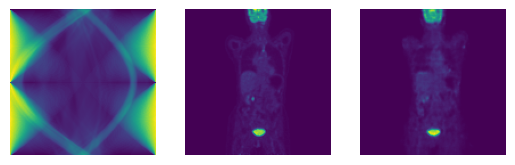

[Epoch 2/50] D_loss: 0.6374 | G_loss: 2.2724


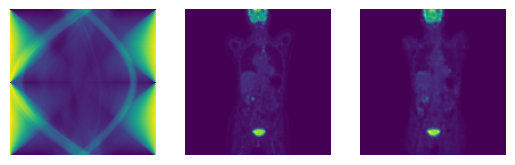

[Epoch 3/50] D_loss: 0.6436 | G_loss: 2.1934


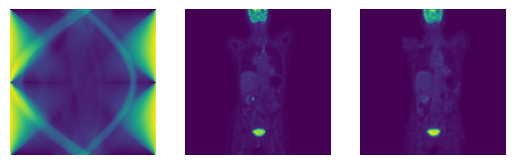

[Epoch 4/50] D_loss: 0.6427 | G_loss: 2.0931


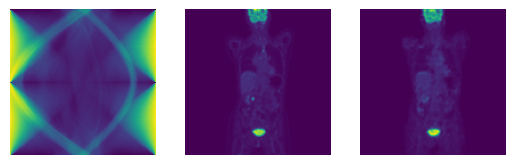

[Epoch 5/50] D_loss: 0.6336 | G_loss: 2.0974


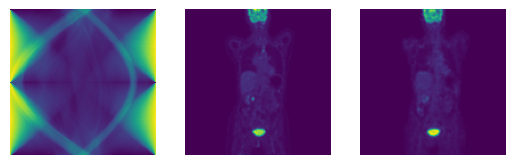

[Epoch 6/50] D_loss: 0.6314 | G_loss: 2.1523


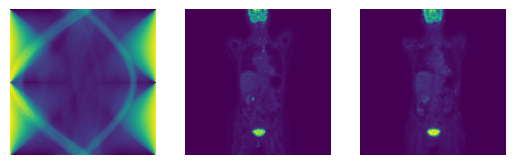

[Epoch 7/50] D_loss: 0.6269 | G_loss: 2.1396


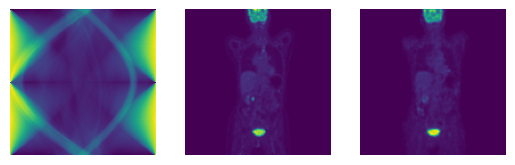

[Epoch 8/50] D_loss: 0.6422 | G_loss: 2.1309


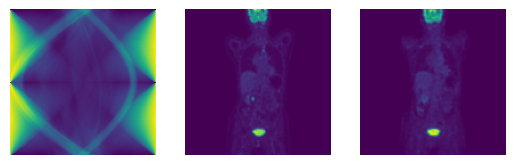

[Epoch 9/50] D_loss: 0.6520 | G_loss: 2.2037


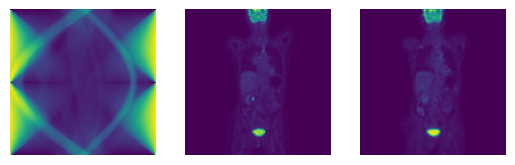

[Epoch 10/50] D_loss: 0.6435 | G_loss: 2.1251


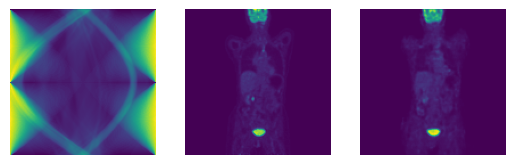

[Epoch 11/50] D_loss: 0.6472 | G_loss: 2.1949


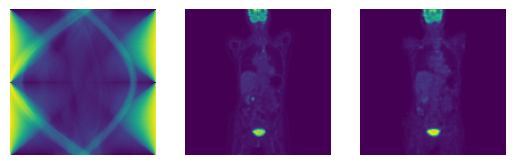

[Epoch 12/50] D_loss: 0.6602 | G_loss: 2.0837


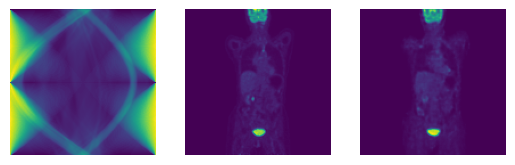

[Epoch 13/50] D_loss: 0.6561 | G_loss: 2.1564


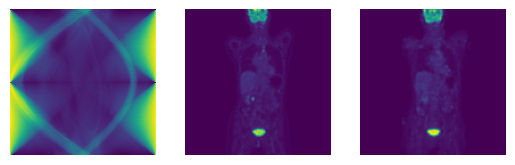

[Epoch 14/50] D_loss: 0.6344 | G_loss: 2.1250


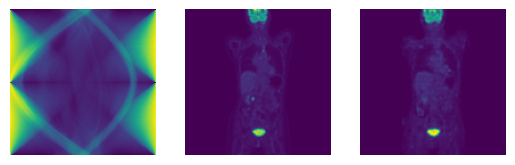

[Epoch 15/50] D_loss: 0.6062 | G_loss: 2.2309


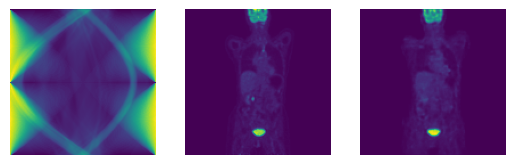

[Epoch 16/50] D_loss: 0.6280 | G_loss: 2.0672


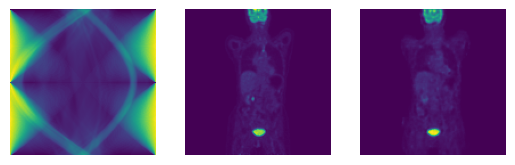

[Epoch 17/50] D_loss: 0.6259 | G_loss: 2.2616


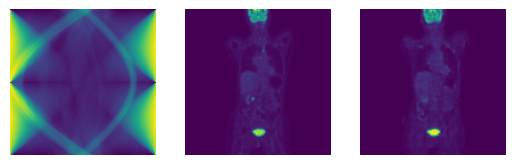

[Epoch 18/50] D_loss: 0.6235 | G_loss: 2.2826


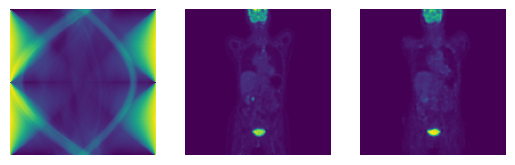

[Epoch 19/50] D_loss: 0.6382 | G_loss: 2.2458


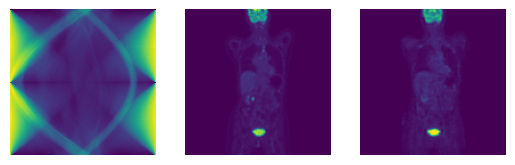

[Epoch 20/50] D_loss: 0.6315 | G_loss: 2.1619


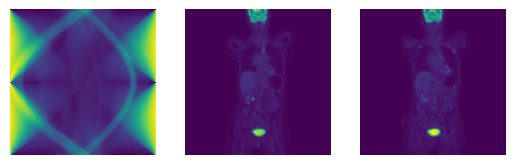

[Epoch 21/50] D_loss: 0.6270 | G_loss: 2.2096


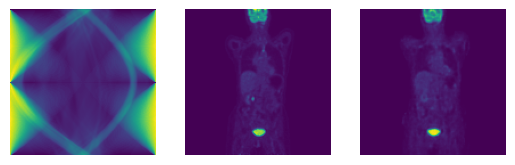

[Epoch 22/50] D_loss: 0.6335 | G_loss: 2.1962


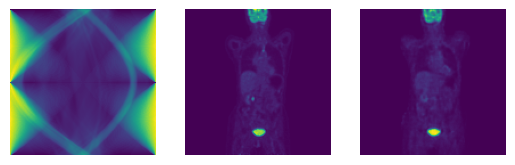

[Epoch 23/50] D_loss: 0.6386 | G_loss: 2.2431


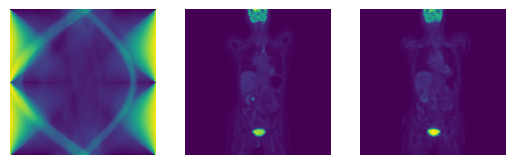

[Epoch 24/50] D_loss: 0.6395 | G_loss: 2.0363


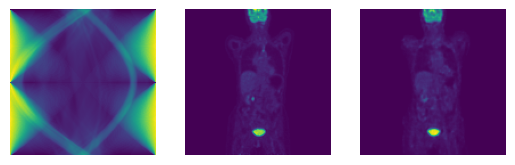

[Epoch 25/50] D_loss: 0.6151 | G_loss: 2.2095


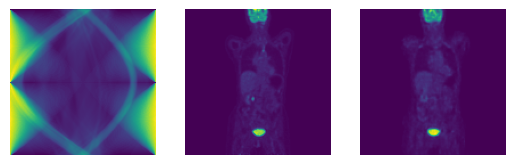

[Epoch 26/50] D_loss: 0.6156 | G_loss: 2.2674


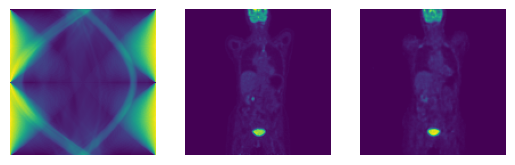

[Epoch 27/50] D_loss: 0.6295 | G_loss: 2.3042


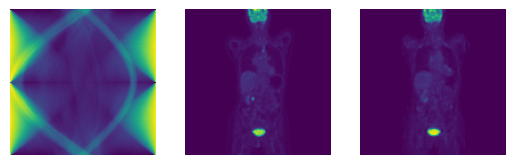

[Epoch 28/50] D_loss: 0.6286 | G_loss: 2.2965


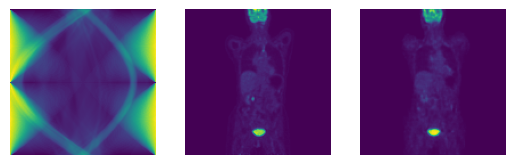

[Epoch 29/50] D_loss: 0.6302 | G_loss: 2.3027


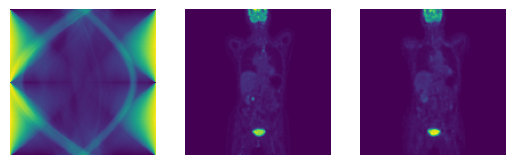

[Epoch 30/50] D_loss: 0.6282 | G_loss: 2.3941


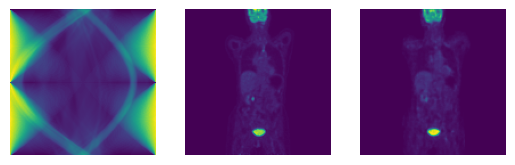

[Epoch 31/50] D_loss: 0.6149 | G_loss: 2.1914


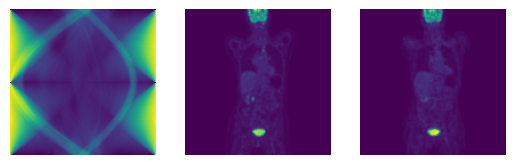

[Epoch 32/50] D_loss: 0.6206 | G_loss: 2.3194


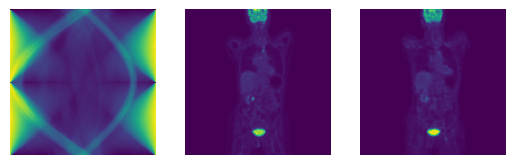

[Epoch 33/50] D_loss: 0.6379 | G_loss: 2.1652


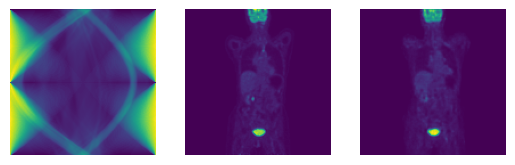

[Epoch 34/50] D_loss: 0.6409 | G_loss: 2.2723


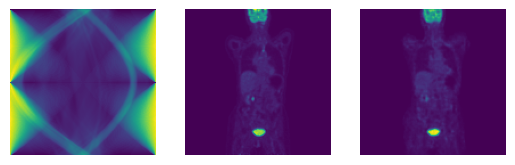

[Epoch 35/50] D_loss: 0.6312 | G_loss: 2.2701


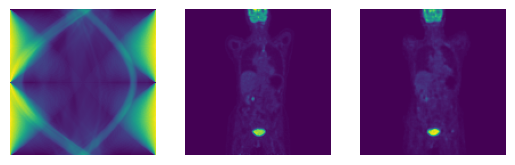

[Epoch 36/50] D_loss: 0.6347 | G_loss: 2.3143


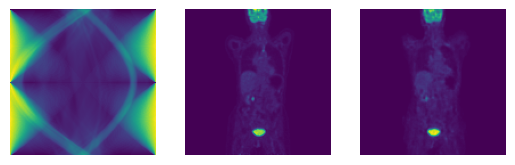

KeyboardInterrupt: 

In [13]:
# -----------------------------
# Training loop
# -----------------------------
import matplotlib.pyplot as plt
for epoch in range(epochs):
    for pet_real, sino_real in train_dl:
        pet_real = pet_real.to(device)
        sino_real = sino_real.to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        pet_fake = G(sino_real)

        pred_real = D(sino_real, pet_real)
        pred_fake = D(sino_real, pet_fake.detach())

        valid = torch.full_like(pred_real, 0.9)
        fake  = torch.full_like(pred_fake, 0.1)

        d_loss = (adversarial_loss(pred_real, valid) + adversarial_loss(pred_fake, fake)) / 2
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()
        adv_loss = adversarial_loss(D(sino_real, pet_fake), torch.ones_like(pred_fake))
        l1_loss = F.l1_loss(pet_fake, pet_real)
        g_loss = adv_loss + lambda_L1 * l1_loss
        g_loss.backward()
        optimizer_G.step()
        

    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")
    fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
    ax1.set_axis_off()
    ax2.set_axis_off()
    ax3.set_axis_off()
    ax1.imshow(sino_real.cpu().detach().numpy()[0][2].reshape(crop,crop))
    ax2.imshow(pet_real.cpu().detach().numpy()[0][2].reshape(crop,crop))
    ax3.imshow(pet_fake.cpu().detach().numpy()[0][2].reshape(crop,crop))
    plt.show()

print("Training complete!")

In [14]:
torch.save(G.state_dict(), 'GanReconstructionModels/GeneratorModel.pth')

In [ ]:
print(sino_real.cpu().detach().numpy().shape)

(16, 4, 128, 128)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2

import cv2
image = []
sinograms = []

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(crop),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
Pet_Test = ImageFolder("D:/New folder/TestDatasetFullImages/", transform=transform)
for i in range(400,500):
    #Dir = r'D:\New folder\TestDatasetFullImages/Test/'+os.listdir(r'D:\New folder\TestDatasetFullImages/Test/')[i]
    #print(Dir)
    im,_ = Pet_Test[i]#cv2.imread(Dir,cv2.IMREAD_GRAYSCALE)
    
    sino = compute_sinogram((im))
    image.append(im)
    sinograms.append(sino)




In [ ]:
sinograms_p = torch.stack(sinograms)
GeneratedImages = []
dataset = MultiSliceDataset(
    Pet_Test,
    sinograms_p,
    num_images,
    crop_size=crop
)

train_dl = DataLoader(dataset, batch_size=1, shuffle=False)
counter = 100
for _,i in train_dl:
    
    pred = G(i.to(device))
    GeneratedImages.append(pred.cpu().detach().numpy()[0][0])
    counter-=1
    if counter == 0:
        break
len(GeneratedImages)

IndexError: index 100 is out of bounds for dimension 0 with size 100

(97, 128, 128)


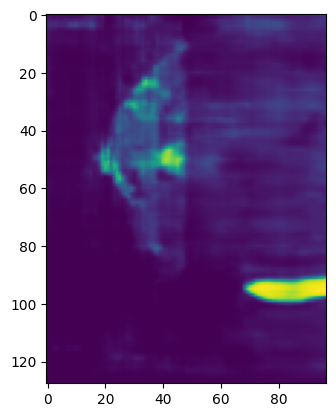

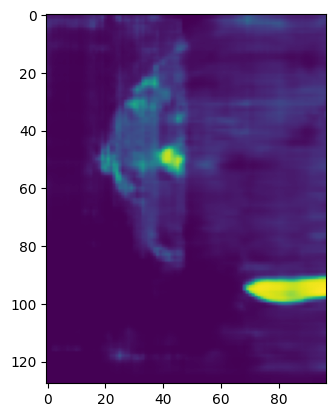

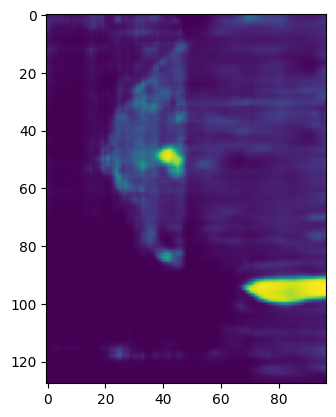

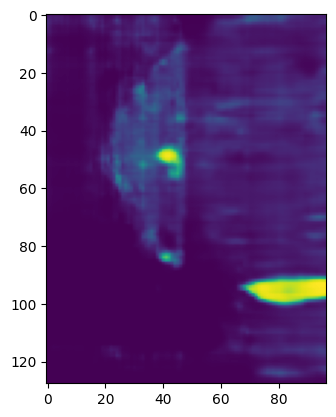

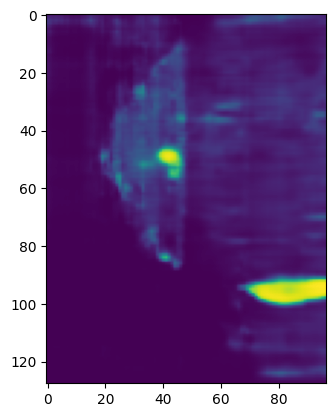

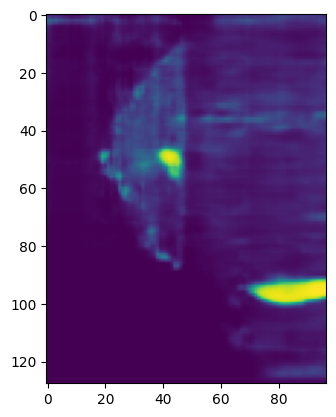

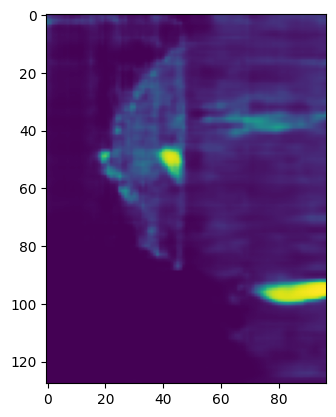

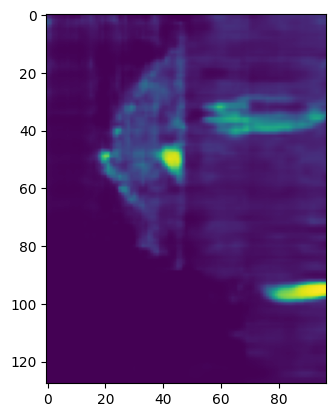

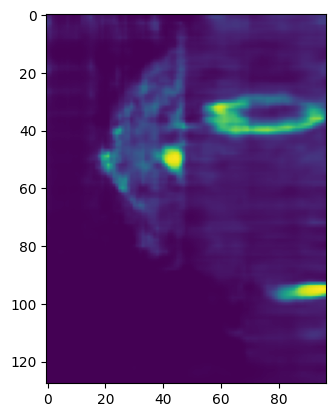

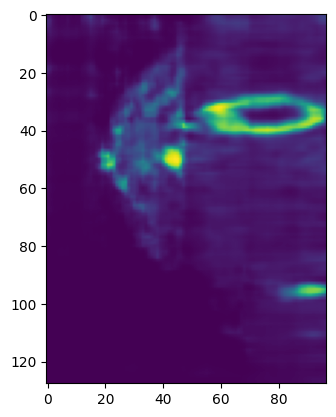

In [ ]:
#print(GeneratedImages[4].cpu().detach().numpy().shape)
print(np.asarray(GeneratedImages).shape)
for i in range(0,10):
    plt.imshow(np.asarray(GeneratedImages).T[60+i])
    plt.show()

In [ ]:
np.array(image).shape

(300, 409, 400)

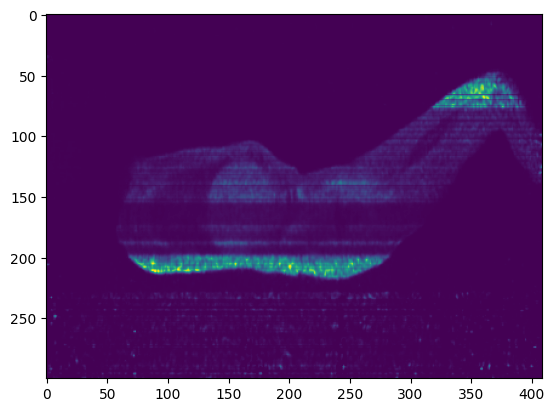

In [ ]:
plt.imshow(np.array(image)[:,:,150])


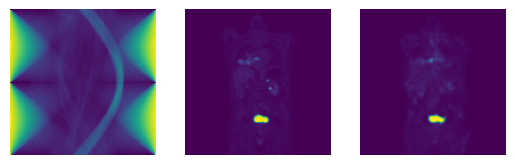

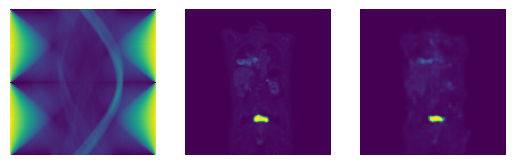

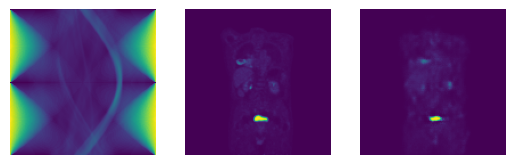

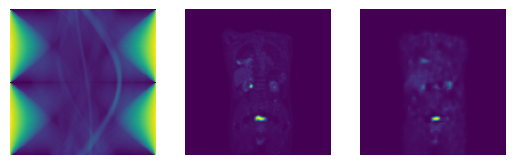

In [ ]:
for i in range(0,16,4):
    #print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")
    fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
    ax1.set_axis_off()
    ax2.set_axis_off()
    ax3.set_axis_off()
    ax1.imshow(sino_real.cpu().detach().numpy()[i][0].reshape(crop,crop))
    ax2.imshow(pet_real.cpu().detach().numpy()[i][0].reshape(crop,crop))
    ax3.imshow(pet_fake.cpu().detach().numpy()[i][0].reshape(crop,crop))
    plt.show()

In [ ]:

#sino_real = sino_real.to(device)

#pet_real = pet_real.view(batch_size, num_images, 1, crop, crop)
#sino_real = sino_real.view(batch_size, num_images, 1, crop, crop)

# -----------------------------
# Train Discriminator
# -----------------------------
optimizer_D.zero_grad()

pet_fake = G(sino_real)
import matplotlib.pyplot as plt
plt.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()
plt.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()
plt.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

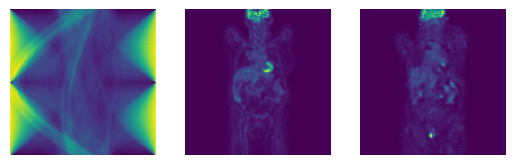

In [ ]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax1.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
ax2.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
ax3.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))